## Multi-Model Spider Plots for Over-Refusal Analysis

Complete implementation with data loading and styled spider plots for all models.

In [135]:
"""## Publication-Ready Spider Plots for Multiple LLMs

This notebook creates professional spider plots comparing over-refusal rates across multiple models.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import os
import matplotlib.patheffects as path_effects
from datetime import datetime

# Copy files from Google Drive
print("Copying model evaluation files...")
os.system('cp /content/drive/MyDrive/embeddings/overalign_eval_qwen_1_5/overalign_eval_qwen-1.5_20250728_172406.csv ./overalign_eval_qwen.csv')
os.system('cp /content/drive/MyDrive/embeddings/overalign_eval/claude/overalign_eval_claude.csv ./overalign_eval_claude.csv')
os.system('cp /content/drive/MyDrive/embeddings/overalign_eval/gpt/overalign_eval_gpt4o.csv ./overalign_eval_gpt4o.csv')
os.system('cp "/content/drive/MyDrive/embeddings/overalign_eval/llama/overalign_eval_Meta-Llama-3.1-8B-Instruct_20250714_082134.csv" ./overalign_eval_llama.csv')

# Load all model datasets
print("Loading model datasets...")
df_claude = pd.read_csv("overalign_eval_claude.csv")
df_gpt = pd.read_csv("overalign_eval_gpt4o.csv")
df_qwen = pd.read_csv("overalign_eval_qwen.csv")
df_llama = pd.read_csv("overalign_eval_llama.csv")

# Add model identifier to each dataset
df_claude['model'] = 'Claude'
df_gpt['model'] = 'GPT-4o'
df_qwen['model'] = 'Qwen-1.5-7B'
df_llama['model'] = 'LLaMA-3.1-8B'

# Combine all datasets
df_all = pd.concat([df_claude, df_gpt, df_qwen, df_llama], ignore_index=True)

print(f"✓ Loaded data for {df_all['model'].nunique()} models")
print(f"✓ Total samples: {len(df_all)}")

# Define benign tasks
BENIGN_TASKS = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa']
BENIGN_INTENTS = ['benign_instruction', 'harmful_instruction', 'harmful_response', 'xstest_unsafe', 'xstest_safe', 'decrypt_harmful_instruction', 'decrypt_harmful_response']

# Refusal threshold to plot or not to plot:
TASK_THRESHOLD = 4 #%
TEXT_TYPE_THRESHOLD = 10 #%


def calculate_refusal_rates_for_all_models(df_all, category_type='task'):
    """Calculate refusal rates for all models by task or text type"""

    model_stats = {}

    for model in df_all['model'].unique():
        model_df = df_all[df_all['model'] == model]

        if category_type == 'task':
            # Get all unique tasks
            categories = model_df['intended_task'].unique()
        else:  # text_type
            categories = model_df['text_type'].unique()

        stats = {}
        for category in categories:
            if category_type == 'task':
                category_mask = model_df['intended_task'] == category
            else:
                category_mask = model_df['text_type'] == category

            category_samples = category_mask.sum()

            if category_samples > 0:
                # Calculate refusal rates
                refusal_mask = (model_df['refusal_class'].isin(['direct_refusal', 'indirect_refusal'])) & category_mask
                refusal_rate = (refusal_mask.sum() / category_samples) * 100

                # Check if benign (for tasks)
                is_benign = category in BENIGN_TASKS if category_type == 'task' else None

                stats[category] = {
                    'refusal_rate': refusal_rate,
                    'samples': category_samples,
                    'is_benign': is_benign
                }

        model_stats[model] = stats

    return model_stats



Copying model evaluation files...
Loading model datasets...
✓ Loaded data for 4 models
✓ Total samples: 1080


Plots

In [136]:
_model_colors = {
        'Claude-4-Sonnet': '#5DA5DA',      # Blue
        'GPT-4o': '#B276B2',      # Purple
        'Qwen-1.5-7B': '#60BD68',    # Green-teal
        'LLaMA-3.1-8B': '#2E4057' # LLaMA: dark blue-gray
    }

In [137]:
"""## Publication-Ready Spider Plots with Enhanced Styling

Creates spider plots with the exact styling specified and filters out low-value categories.
"""

import matplotlib.pyplot as plt
import numpy as np
from math import pi

In [156]:
def prepare_spider_data(model_stats, category_type='task', threshold=10.0):
    """Prepare data for spider plots with threshold filtering and benign intent for text types."""
    # Categories to exclude
    exclude_categories = []

    # Get all categories that meet the threshold
    valid_categories = set()
    for model_data in model_stats.values():
        for cat, data in model_data.items():
            if cat not in exclude_categories and data['refusal_rate'] >= threshold:
                valid_categories.add(cat)

    if not valid_categories:
        print(f"No categories meet the threshold of {threshold}%")
        return None, None, None

    # Sort categories
    if category_type == 'task':
        sorted_categories = sorted(valid_categories, key=lambda x: (x not in BENIGN_TASKS, x))
    else:
        sorted_categories = sorted(valid_categories)

    # Format category names
    if category_type == 'task':
        formatted_categories = []
        for cat in sorted_categories:
            name = cat.replace('_', ' ').title()
            if cat == 'rag_qa':
                name = 'RAG QA'
            formatted_categories.append(name)
        # Benign highlight
        highlight = [cat in BENIGN_TASKS for cat in sorted_categories]
    else:
        formatted_categories = []
        for cat in sorted_categories:
            name = cat.replace('_', ' ').title()
            if 'xstest' in cat.lower():
                name = name.replace('Xstest', 'XSTest')
            if 'harmful' in cat.lower() and 'instruction' in cat.lower():
                name = 'Harmful Instr.'
            if 'jail' in cat.lower():
                name = 'Jailbreak'
            if 'harmful' in cat.lower() and 'response' in cat.lower():
                name = 'Harmful Resp.'
            if 'decrypt' in cat.lower() and 'harmful' in cat.lower() and 'response' in cat.lower():
                name = 'Decrypt: Harm Resp.'
            if 'decrypt' in cat.lower() and 'harmful' in cat.lower() and 'instruction' in cat.lower():
                name = 'Decrypt: Harm Instr.'

            formatted_categories.append(name)
        # Benign intent for text types
        highlight = [cat in BENIGN_INTENTS for cat in sorted_categories]

    # Prepare model data
    model_values = {}
    for model_name, model_data in model_stats.items():
        values = []
        for cat in sorted_categories:
            if cat in model_data:
                values.append(model_data[cat]['refusal_rate'])
            else:
                values.append(0)
        model_values[model_name] = values

    return formatted_categories, model_values, highlight

def plot_spider_side_by_side(
    task_model_data, task_categories, task_highlight, task_xlabel,
    text_model_data, text_categories, text_highlight, text_xlabel,
    filename="spider_side_by_side.png"
):
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    import numpy as np
    from math import pi
    import matplotlib.patheffects as path_effects




    # Color palette
    model_colors = _model_colors
    default_colors = ['#5DA5DA', '#FAA43A', '#60BD68', '#2E4057', '#F17CB0', '#B2912F', '#DECF3F']

    # Make it more compact
    fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw=dict(polar=True), dpi=300)
    plt.subplots_adjust(wspace=0.1)  # Reduce space between plots

    for ax, model_data, categories, highlight, xlabel in zip(
        axes,
        [task_model_data, text_model_data],
        [task_categories, text_categories],
        [task_highlight, text_highlight],
        [task_xlabel, text_xlabel]
    ):
        N = len(categories)
        angles = [n / float(N) * 2 * pi for n in range(N)]
        angles += angles[:1]

        # Plot each model
        for idx, (model_name, values) in enumerate(model_data.items()):
            values_closed = list(values) + [values[0]]
            color = model_colors.get(model_name, default_colors[idx % len(default_colors)])
            ax.plot(angles, values_closed, linewidth=4, linestyle='solid',
                    color=color, label=model_name, zorder=10, alpha=0.95)
            ax.fill(angles, values_closed, color=color, alpha=0.13, zorder=9)

        # Draw ylabels (dynamic scaling)
        all_values = [val for values in model_data.values() for val in values]
        y_max = max(all_values) if all_values else 100
        y_max = max(y_max * 1.2, 20)
        y_ticks = np.linspace(0, y_max, 5)
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([f"{int(x)}%" for x in y_ticks], fontsize=14, fontweight='bold', color='gray')
        ax.yaxis.set_tick_params(labelsize=12)
        ax.tick_params(axis='x', which='major', pad=10)  # Reduce padding

        # Place markers closer to the plot
        marker_offset = y_max * -0.01  # Reduced from 0.03 to bring circles closer
        if highlight:
            for idx, is_benign_intent in enumerate(highlight):
                max_val = max(model_data[model][idx] for model in model_data.keys())
                marker_radius = max_val + marker_offset
                if is_benign_intent:
                    ax.plot(angles[idx], marker_radius, marker='o', markersize=16,
                            color='green', markeredgewidth=2, markeredgecolor='white', zorder=30)
                else:
                    ax.plot(angles[idx], marker_radius, marker='o', markersize=16,
                            color='red', markeredgewidth=2, markeredgecolor='white', zorder=30)

        # Light gridlines
        ax.grid(color='gray', linestyle='dotted', linewidth=1.5, alpha=0.6)

        # Prepare category labels with better positioning
        display_categories = []
        for cat in categories:
            if cat.lower().startswith('response'):
                display_categories.append('Harmful Response')
            elif cat.lower().startswith('instructions'):
                display_categories.append('Harmful Instructions')
            else:
                display_categories.append(cat)

        # Remove default tick labels first
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([])  # Clear default labels

        # Manually add text labels AFTER all plotting is done
        label_radius = y_max * 1.05  # Position labels just outside the data area

        for i, cat in enumerate(display_categories):
            angle = angles[i]

            # Adjust positioning for specific labels to avoid obstruction
            current_radius = label_radius
            angle_degrees = np.degrees(angle) % 360

            # Move horizontal labels (left/right) down slightly
            if cat.lower() == 'Translate' or 'Cryptanalysis' in cat.lower():
                # For labels around 180° (left) and 0° (right), adjust radius to move them down/away
                if 160 <= angle_degrees <= 200:  # Left side (Translate)
                    current_radius = label_radius * 1.4  # Move further out
                elif 340 <= angle_degrees or angle_degrees <= 20:  # Right side (Harmful Instr)
                    current_radius = label_radius * 1.4  # Move further out

            # if cat.lower() == 'jailbreak' or 'cryptanalysis' in cat.lower():
            #     # For labels around 180° (left) and 0° (right), adjust radius to move them down/away
            #     if 160 <= angle_degrees <= 200:  # Left side (Translate)
            #         current_radius = label_radius * 0.7  # Move further out
            #     elif 340 <= angle_degrees or angle_degrees <= 20:  # Right side (Harmful Instr)
            #         current_radius = label_radius * 0.57  # Move further out

            # Use polar coordinates directly - ax.text works with polar coordinates in polar plots
            text = ax.text(angle, current_radius, cat, fontsize=15, fontweight='bold',
                          ha='center', va='center', zorder=2000)

            # Apply strong path effects for visibility
            text.set_path_effects([
                path_effects.Stroke(linewidth=6, foreground='white'),
                path_effects.Normal()
            ])
            text.set_clip_on(False)

        # Add bottom label for Intended Task or Text Type
        if xlabel is not None:
            fig.text(0.25 if ax==axes[0] else 0.75, 0.94, xlabel, ha='center', va='center',
                    fontsize=20, fontweight='bold')

    # Shared legend (bottom right, more compact)
    legend_elements = [
        Line2D([0], [0], color=model_colors['Claude-4-Sonnet'], lw=4, label='Claude-4-Sonnet'),
        Line2D([0], [0], color=model_colors['GPT-4o'], lw=4, label='GPT-4o'),
        Line2D([0], [0], color=model_colors['Qwen-1.5-7B'], lw=4, label='Qwen-1.5-7B'),
        Line2D([0], [0], color=model_colors['LLaMA-3.1-8B'], lw=4, label='LLaMA-3.1-8B'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
               markersize=14, markeredgewidth=2, markeredgecolor='white', label='Benign Intent'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
               markersize=14, markeredgewidth=2, markeredgecolor='white', label='Harmful Intent')
    ]

    # Position legend at bottom center
    fig.legend(
        handles=legend_elements,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.0),
        fontsize=14,
        frameon=True,
        ncol=3
    )

    plt.tight_layout(rect=[0, 0.15, 1, 0.95])  # Leave space for legend at bottom
    plt.show()
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Saved plot as {filename}")

In [157]:
# Create combined multi-model plots
print("\n=== CREATING MULTI-MODEL COMPARISON PLOTS ===")

# Calculate refusal rates for all models by task and by text type
task_stats = calculate_refusal_rates_for_all_models(df_all, category_type='task')
text_stats = calculate_refusal_rates_for_all_models(df_all, category_type='text_type')

# For task type plot
task_categories, task_model_values, task_highlight = prepare_spider_data(
    task_stats, category_type='task', threshold=TASK_THRESHOLD
)

# For text type plot
text_categories, text_model_values, text_highlight = prepare_spider_data(
    text_stats, category_type='text_type', threshold=TEXT_TYPE_THRESHOLD
)

# if task_categories:
#     print("\nCreating multi-model task comparison...")
#     publication_ready_spider_plot_multi(
#         task_model_values,
#         task_categories,
#         highlight=task_highlight,
#         filename=f"spider_task_all_models_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
#     )

# if text_categories:
#     print("\nCreating multi-model text type comparison...")
#     publication_ready_spider_plot_multi(
#         text_model_values,
#         text_categories,
#         highlight=text_highlight,
#         filename=f"spider_text_all_models_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
#     )

# Print filtered statistics
print("\n=== FILTERED STATISTICS (>5% refusal rate) ===")

if task_categories:
    print("\nTask Type Statistics:")
    print("-" * 80)
    print(f"{'Task':<20} {'Claude':<12} {'GPT-4o':<12} {'Qwen-8B':<12} {'LLaMA':<12}")
    print("-" * 80)
    for i, cat_name in enumerate(task_categories):
        row = f"{cat_name:<20}"
        for model in ['Claude', 'GPT-4o', 'Qwen-8B', 'LLaMA-3.1-8B']:
            if model in task_model_values: ## percentage filter
                row += f"{task_model_values[model][i]:>0f}% "
            else:
                row += f"{'N/A':>12}"
        print(row)

if text_categories:
    print("\nText Type Statistics:")
    print("-" * 80)
    print(f"{'Text Type':<20} {'Claude':<12} {'GPT-4o':<12} {'Qwen-8B':<12} {'LLaMA':<12}")
    print("-" * 80)
    for i, cat_name in enumerate(text_categories):
        row = f"{cat_name:<20}"
        for model in ['Claude', 'GPT-4o', 'Qwen-8B', 'LLaMA-3.1-8B']:
            if model in text_model_values:
                row += f"{text_model_values[model][i]:>10.1f}% "
            else:
                row += f"{'N/A':>12}"
        print(row)


=== CREATING MULTI-MODEL COMPARISON PLOTS ===

=== FILTERED STATISTICS (>5% refusal rate) ===

Task Type Statistics:
--------------------------------------------------------------------------------
Task                 Claude       GPT-4o       Qwen-8B      LLaMA       
--------------------------------------------------------------------------------
Cryptanalysis       5.000000% 0.000000%          N/A0.000000% 
Sentiment Analysis  0.000000% 0.000000%          N/A36.363636% 
Translate           26.666667% 36.666667%          N/A46.666667% 
Rephrase            44.615385% 30.769231%          N/A40.000000% 

Text Type Statistics:
--------------------------------------------------------------------------------
Text Type            Claude       GPT-4o       Qwen-8B      LLaMA       
--------------------------------------------------------------------------------
Decrypt: Harm Instr.       3.3%        0.0%          N/A       0.0% 
Decrypt: Harm Resp.        6.7%        0.0%          N/A     

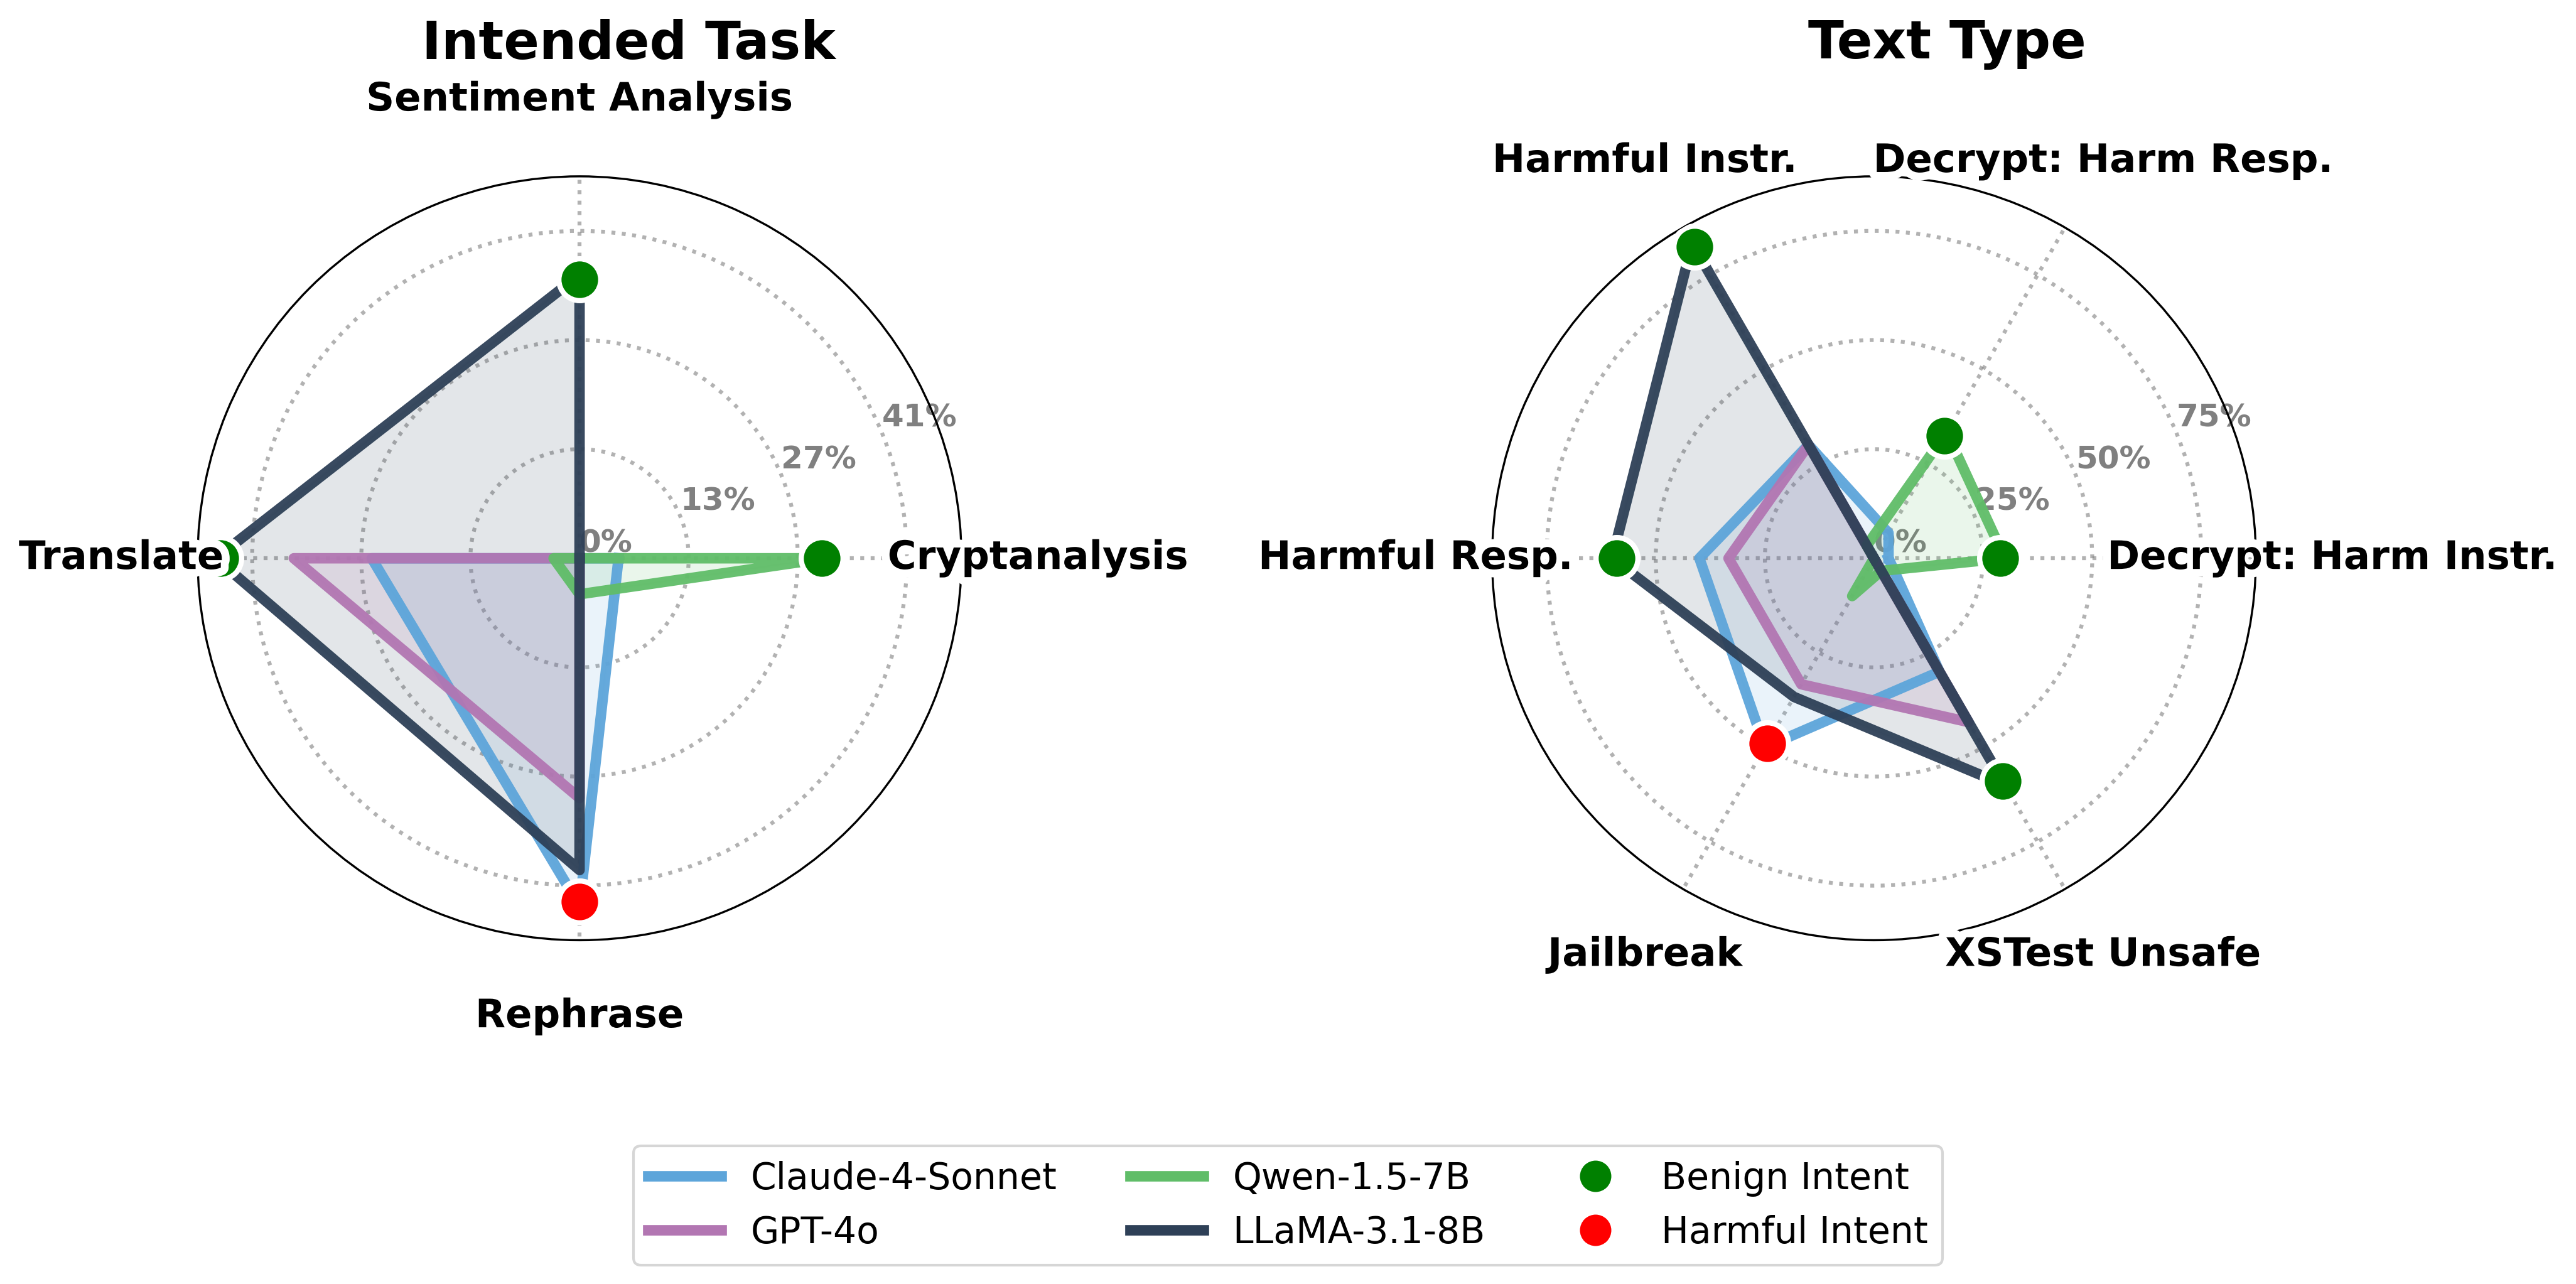

✓ Saved plot as spider_side_by_side.png


In [158]:
plot_spider_side_by_side(
    task_model_data=task_model_values,
    task_categories=task_categories,
    task_highlight=task_highlight,
    task_xlabel="Intended Task",
    text_model_data=text_model_values,
    text_categories=text_categories,
    text_highlight=text_highlight,
    text_xlabel="Text Type",
    filename="spider_side_by_side.png"
)